# Notebook 07 — End-to-End-Pipeline-Latenz

**Ziel:** Die sequentielle Voice-Pipeline (STT → LLM → TTS) durchrechnen und alle 27
Provider-Kombinationen (3 × 3 × 3) vergleichen.

**Forschungsfrage:** Erreicht eine kommerzielle Cold-Start-Voice-Pipeline das 1-Sekunden-Budget
aus Nutzersicht? Welche Kombination ist optimal — und wo liegt der Flaschenhals?

**Szenario — Cold-Start Streaming** (`stt_connect + stt_ttft + llm_ttft + tts_ttfa`):
Das LLM startet, sobald das erste abgeschlossene STT-Ergebnis vorliegt (reale Streaming-Pipeline).
STT, LLM und TTS bauen jeweils neue Verbindungen auf (Cold-Start). LLM `ttft_ms` und TTS
`ttfa_ms` sind bereits connect-inklusiv (separate Connect-Messung in den Modulen, analog zu
NB 04 und NB 05).

> **Hinweis — kein Batch-Szenario.** Eine frühere Fassung stellte dem Streaming ein
> „Batch"-Szenario auf Basis von `stt_total_ms` gegenüber. Das ist **nicht zulässig**:
> `total_ms` wird je STT-Provider unterschiedlich abgegriffen. Deepgrams Empfangsschleife
> liest bis zum WebSocket-Close (~3,4 s Leerlauf-Tail *nach* dem letzten Final), Azure und
> Rev.ai brechen beim ersten Final ab. Die scheinbare „Batch"-Differenz war damit ein
> **Mess-Artefakt dieses Tails** (Δ Deepgram exakt 3 351 ms, Azure 4 ms), kein Provider-Effekt —
> und die Tail-Zeit ist *kein* Audio-Transfer (`send_ms` ≈ 137 ms). `total_ms` wird daher nur
> provider-intern interpretiert (NB 03); die E2E-Pipeline wird ausschließlich im
> Streaming-Szenario berichtet.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools

from _helpers import load_layer3, save_figure, save_table, PROVIDER_COLORS

stt = load_layer3('stt')
llm = load_layer3('llm')
tts = load_layer3('tts')

print(f'STT: {len(stt):,} Zeilen | Provider: {sorted(stt.api.unique())}')
print(f'LLM: {len(llm):,} Zeilen | Provider: {sorted(llm.api.unique())}')
print(f'TTS: {len(tts):,} Zeilen | Provider: {sorted(tts.api.unique())}')

STT: 16,227 Zeilen | Provider: ['azure', 'deepgram', 'revai']
LLM: 14,729 Zeilen | Provider: ['groq', 'mistral', 'openai']
TTS: 16,796 Zeilen | Provider: ['azure', 'deepgram', 'openai']


## 1. Pipeline-Modell: Mediane pro Provider

Wir berechnen zunächst die Median-Latenzen pro Provider, dann addieren wir alle
27 Kombinationen (Median-Addition als konservative Schätzung — die echte E2E-Latenz
schwankt stärker, aber der Median ist reproduzierbar und fair vergleichbar).

**Metriken (Cold-Start Streaming):**
- STT: `stt_connect_ms + stt_ttft_ms` (disjunkte Phasen laut Messcode)
- LLM: `llm_ttft_ms` (connect-inklusiv)
- TTS: `tts_ttfa_ms` (connect-inklusiv)

`stt_total_ms` wird nur als provider-interne Referenz ausgewiesen (nicht cross-Provider
vergleichbar — s. Hinweis oben) und geht **nicht** in die E2E-Summe ein.

In [2]:
# --- Mediane pro Provider ---
stt_med = stt.groupby('api')[['connect_ms', 'ttft_ms', 'total_ms']].median()
stt_med['stream_ms'] = stt_med['connect_ms'] + stt_med['ttft_ms']  # Cold-Start Streaming

llm_med = llm.groupby('api')[['connect_ms', 'ttft_ms']].median()
llm_med['e2e_ms'] = llm_med['ttft_ms']

tts_med = tts.groupby('api')[['connect_ms', 'ttfa_ms']].median()
tts_med['e2e_ms'] = tts_med['ttfa_ms']

print('=== STT Mediane (ms) ===')
print('(total_ms nur provider-intern — nicht cross-Provider vergleichbar)')
print(stt_med[['connect_ms', 'ttft_ms', 'total_ms', 'stream_ms']].round(1))
print('\n=== LLM Mediane (ms) ===')
print(llm_med[['connect_ms', 'ttft_ms']].round(1))
print('\n=== TTS Mediane (ms) ===')
print(tts_med[['connect_ms', 'ttfa_ms']].round(1))

=== STT Mediane (ms) ===
(total_ms nur provider-intern — nicht cross-Provider vergleichbar)
          connect_ms  ttft_ms  total_ms  stream_ms
api                                               
azure           49.5   1715.2    1768.8     1764.7
deepgram       424.9    574.6    4350.6      999.4
revai          597.5   1419.6    2116.5     2017.1

=== LLM Mediane (ms) ===
         connect_ms  ttft_ms
api                         
groq            9.6     68.2
mistral         9.1    230.6
openai          9.4    541.5

=== TTS Mediane (ms) ===
          connect_ms  ttfa_ms
api                          
azure           33.3     66.6
deepgram       290.8    556.5
openai           9.2    954.2


In [3]:
# --- 27 Kombinationen aufbauen (Cold-Start Streaming) ---
rows = []
for stt_p, llm_p, tts_p in itertools.product(
        stt_med.index, llm_med.index, tts_med.index):

    s_conn  = stt_med.loc[stt_p, 'connect_ms']
    s_ttft  = stt_med.loc[stt_p, 'ttft_ms']
    l_ttft  = llm_med.loc[llm_p, 'ttft_ms']
    t_ttfa  = tts_med.loc[tts_p, 'ttfa_ms']

    stream_e2e = s_conn + s_ttft + l_ttft + t_ttfa

    rows.append({
        'combo':       f'{stt_p}+{llm_p}+{tts_p}',
        'stt':         stt_p,
        'llm':         llm_p,
        'tts':         tts_p,
        'stt_conn_ms': round(s_conn, 1),
        'stt_ttft_ms': round(s_ttft, 1),
        'llm_ttft_ms': round(l_ttft, 1),
        'tts_ttfa_ms': round(t_ttfa, 1),
        'stream_e2e':  round(stream_e2e, 1),
    })

combos = pd.DataFrame(rows).sort_values('stream_e2e').reset_index(drop=True)

print(f'Kombinationen gesamt: {len(combos)}')
print('\nTop-5 (Streaming):')
print(combos[['combo','stream_e2e']].head(5).to_string(index=False))
print('\nBottom-5 (Streaming):')
print(combos[['combo','stream_e2e']].tail(5).to_string(index=False))

save_table(combos, '07_pipeline_combinations', index=False)

Kombinationen gesamt: 27

Top-5 (Streaming):
                    combo  stream_e2e
      deepgram+groq+azure      1134.2
   deepgram+mistral+azure      1296.7
    deepgram+openai+azure      1607.5
   deepgram+groq+deepgram      1624.1
deepgram+mistral+deepgram      1786.6

Bottom-5 (Streaming):
                combo  stream_e2e
    revai+groq+openai      3039.5
revai+openai+deepgram      3115.1
 revai+mistral+openai      3202.0
  azure+openai+openai      3260.4
  revai+openai+openai      3512.8
  saved tables/07_pipeline_combinations.csv


## 2. Stacked-Bar: Anteil STT / LLM / TTS an der E2E-Latenz

Für alle 27 Kombinationen, sortiert nach Streaming-E2E aufsteigend.
Die Balkenfarbe zeigt, welcher Layer wie viel zur Gesamtlatenz beiträgt.

  saved figures/07_e2e/{png,pdf}/07_e2e_stacked_bar


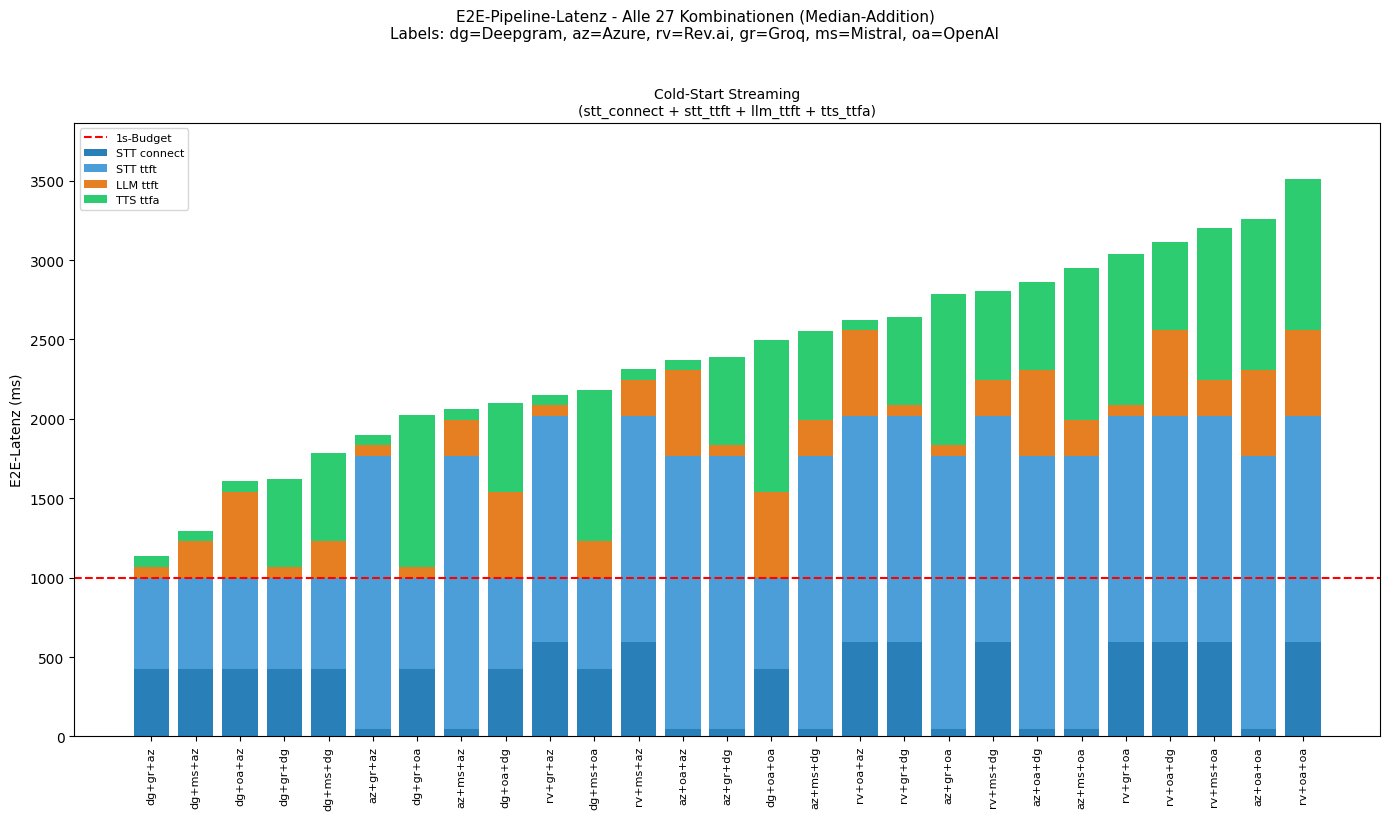

In [4]:
fig, ax = plt.subplots(figsize=(14, 8))

LAYER_COLORS = {
    'STT':  '#4c9ed9',
    'LLM':  '#e67e22',
    'TTS':  '#2ecc71',
    'STT-conn': '#2980b9',
}

ABBREV = {'deepgram': 'dg', 'azure': 'az', 'revai': 'rv', 'groq': 'gr', 'mistral': 'ms', 'openai': 'oa'}
labels = combos['combo'].apply(
    lambda c: '+'.join(ABBREV.get(p, p) for p in c.split('+'))
)
x = np.arange(len(combos))

seg1 = combos['stt_conn_ms']
seg2 = combos['stt_ttft_ms']
seg3 = combos['llm_ttft_ms']
seg4 = combos['tts_ttfa_ms']
ax.bar(x, seg1, color=LAYER_COLORS['STT-conn'], label='STT connect')
ax.bar(x, seg2, bottom=seg1, color=LAYER_COLORS['STT'], label='STT ttft')
ax.bar(x, seg3, bottom=seg1+seg2, color=LAYER_COLORS['LLM'], label='LLM ttft')
ax.bar(x, seg4, bottom=seg1+seg2+seg3, color=LAYER_COLORS['TTS'], label='TTS ttfa')

ax.axhline(1000, color='red', lw=1.5, ls='--', label='1s-Budget')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8, rotation=90, ha='center')
ax.set_ylabel('E2E-Latenz (ms)')
ax.set_title('Cold-Start Streaming\n(stt_connect + stt_ttft + llm_ttft + tts_ttfa)', fontsize=10)
ax.legend(fontsize=8, loc='upper left')
ax.set_ylim(0, combos['stream_e2e'].max() * 1.1)

fig.suptitle('E2E-Pipeline-Latenz - Alle 27 Kombinationen (Median-Addition)\n'
             'Labels: dg=Deepgram, az=Azure, rv=Rev.ai, gr=Groq, ms=Mistral, oa=OpenAI',
             fontsize=11, y=1.02)
plt.tight_layout()
save_figure(fig, '07_e2e_stacked_bar')
plt.show()

## 3. 1-Sekunden-Budget: Horizontale Balken sortiert

Klassische Budget-Darstellung: Alle 27 Streaming-Kombinationen sortiert, mit roter 1s-Linie.

  saved figures/07_e2e/{png,pdf}/07_e2e_budget


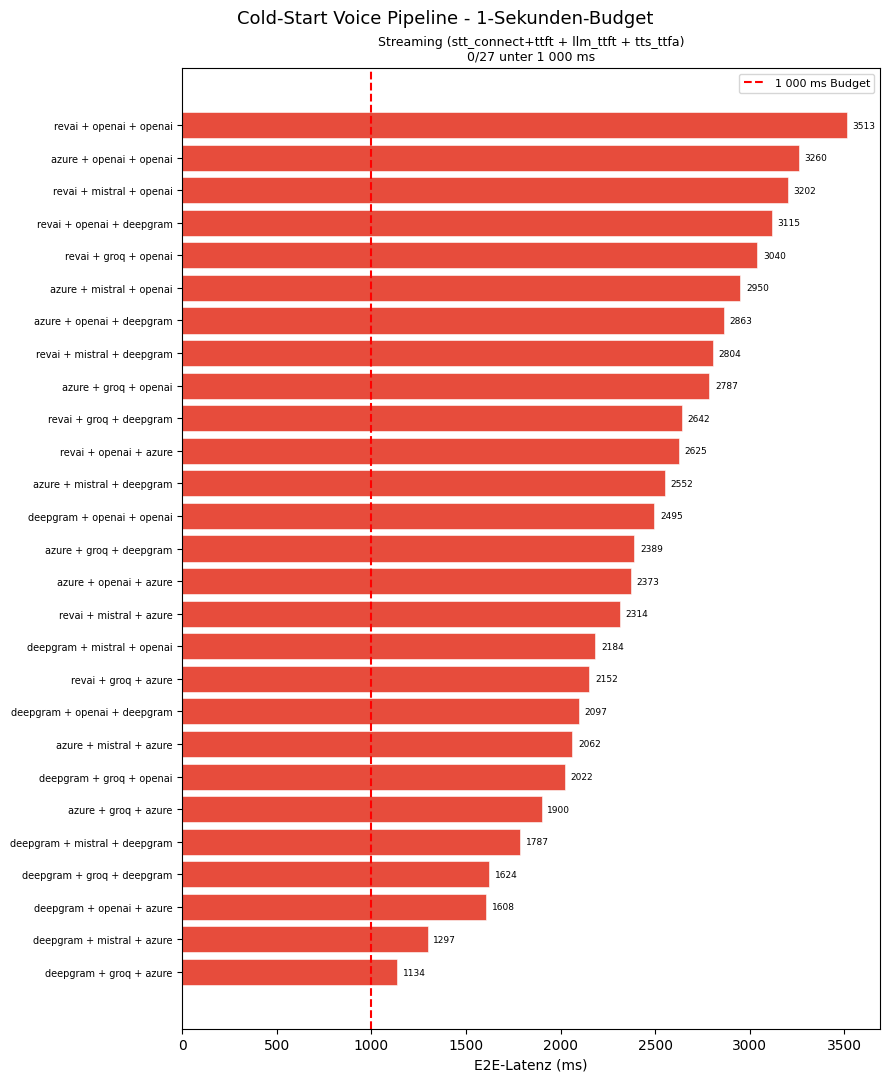

In [5]:
fig, ax = plt.subplots(figsize=(9, 11))

col   = 'stream_e2e'
title = 'Streaming (stt_connect+ttft + llm_ttft + tts_ttfa)'

df = combos.sort_values(col)
y  = np.arange(len(df))
vals = df[col]
colors = ['#e74c3c' if v > 1000 else '#2ecc71' for v in vals]

ax.barh(y, vals, color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(1000, color='red', lw=1.5, ls='--', label='1 000 ms Budget')

for yi in range(len(df)):
    ax.text(vals.iloc[yi] + 30, yi, f"{vals.iloc[yi]:.0f}",
            va='center', fontsize=6.5)

ax.set_yticks(y)
ax.set_yticklabels(df['combo'].str.replace('+', ' + ', regex=False), fontsize=7)
ax.set_xlabel('E2E-Latenz (ms)')
ax.legend(fontsize=8)

under = (vals <= 1000).sum()
ax.set_title(f'{title}\n{under}/27 unter 1 000 ms', fontsize=9)

fig.suptitle('Cold-Start Voice Pipeline - 1-Sekunden-Budget', fontsize=13)
plt.tight_layout()
save_figure(fig, '07_e2e_budget')
plt.show()

## 4. Bottleneck-Analyse: Welcher Layer dominiert?

Pro Kombination: Anteil STT / LLM / TTS an der Gesamtlatenz.
Gezählt wird, in wie vielen der 27 Kombinationen welcher Layer >50 % beiträgt.

In [6]:
# Streaming-Szenario: Anteile berechnen
c = combos.copy()
c['pct_stt'] = (c['stt_conn_ms'] + c['stt_ttft_ms']) / c['stream_e2e'] * 100
c['pct_llm'] = c['llm_ttft_ms'] / c['stream_e2e'] * 100
c['pct_tts'] = c['tts_ttfa_ms'] / c['stream_e2e'] * 100
c['dominant'] = c[['pct_stt','pct_llm','pct_tts']].idxmax(axis=1).str.replace('pct_','').str.upper()

print('Dominierender Layer (Streaming) - Anzahl Kombinationen:')
print(c['dominant'].value_counts())
print()
print('Mittlerer STT-Anteil (Streaming):', c['pct_stt'].mean().round(1), '%')
print('Mittlerer LLM-Anteil (Streaming):', c['pct_llm'].mean().round(1), '%')
print('Mittlerer TTS-Anteil (Streaming):', c['pct_tts'].mean().round(1), '%')

Dominierender Layer (Streaming) - Anzahl Kombinationen:
dominant
STT    27
Name: count, dtype: int64

Mittlerer STT-Anteil (Streaming): 67.4 %
Mittlerer LLM-Anteil (Streaming): 11.8 %
Mittlerer TTS-Anteil (Streaming): 20.8 %


## 5. Zusammenfassungs-Tabelle

Alle 27 Kombinationen mit Streaming-E2E, sortiert nach Streaming-E2E.

In [7]:
display_cols = ['combo', 'stt_conn_ms', 'stt_ttft_ms',
                'llm_ttft_ms', 'tts_ttfa_ms', 'stream_e2e']

print('=== Alle 27 Kombinationen (sortiert nach Streaming-E2E) ===')
print(combos[display_cols].to_string(index=False))

print(f'\nStreaming: Min={combos.stream_e2e.min():.0f} ms, '
      f'Max={combos.stream_e2e.max():.0f} ms, '
      f'Median={combos.stream_e2e.median():.0f} ms')
print(f'\nKombinationen unter 1s Streaming: {(combos.stream_e2e < 1000).sum()}/27')

=== Alle 27 Kombinationen (sortiert nach Streaming-E2E) ===
                    combo  stt_conn_ms  stt_ttft_ms  llm_ttft_ms  tts_ttfa_ms  stream_e2e
      deepgram+groq+azure        424.9        574.6         68.2         66.6      1134.2
   deepgram+mistral+azure        424.9        574.6        230.6         66.6      1296.7
    deepgram+openai+azure        424.9        574.6        541.5         66.6      1607.5
   deepgram+groq+deepgram        424.9        574.6         68.2        556.5      1624.1
deepgram+mistral+deepgram        424.9        574.6        230.6        556.5      1786.6
         azure+groq+azure         49.5       1715.2         68.2         66.6      1899.5
     deepgram+groq+openai        424.9        574.6         68.2        954.2      2021.8
      azure+mistral+azure         49.5       1715.2        230.6         66.6      2062.0
 deepgram+openai+deepgram        424.9        574.6        541.5        556.5      2097.4
         revai+groq+azure        597.5  

## 6. Hauptbefunde

### 6.1 Das 1-Sekunden-Budget wird im Cold-Start nicht erreicht

Alle 27 Kombinationen liegen im Cold-Start-Streaming-Szenario **über 1 000 ms**.
Die beste Kombination (**Deepgram STT + Groq LLM + Azure TTS**) erreicht ~1 134 ms Median:

```
stt_connect (425) + stt_ttft (575) + llm_ttft (68) + tts_ttfa (67) = 1 134 ms
```

### 6.2 STT ist der dominante Flaschenhals

Im Streaming-Szenario entfallen im Schnitt **~67 %** der E2E-Latenz auf STT (connect + ttft).
LLM und TTS sind zusammen für die restlichen ~33 % verantwortlich — selbst mit dem
langsamsten LLM (OpenAI, 542 ms) und TTS (OpenAI, 954 ms) dominiert STT bei Azure und Rev.ai.

### 6.3 Engine-Speed > Netzwerknähe (auch in der Pipeline)

Deepgram (USA, RTT 138 ms) liefert mit 999 ms Cold-Start-STT den besten Streaming-Wert —
obwohl Azure (EU, RTT 10 ms) netzwerknäher ist. Azures STT-Engine (1 769 ms) kompensiert
den Netzwerkvorteil um Faktor ~10.

### 6.4 Cloudflare-Nähe bei LLM/TTS nützt wenig

OpenAI TTS profitiert von Cloudflare-Edge-Nähe (connect ~9 ms), aber die Backend-
Verarbeitungszeit (~945 ms) macht es zum langsamsten TTS-Kandidaten. Azure TTS (67 ms)
gewinnt trotz 11 ms RTT durch eine schnelle Engine.

### 6.5 Produktionsrelevanz

In einer Produktions-Pipeline mit persistenten Verbindungen (Connection Pool)
entfällt `stt_connect_ms` (425 ms bei Deepgram). Die Warm-Connection-Schätzung:

```
stt_ttft (575) + llm_ttft_ohne_connect (68-10=58) + tts_ttfa_ohne_connect (67-33=33) ≈ 666 ms
```

→ Mit persistenten Verbindungen wäre Deepgram+Groq+Azure **unter 700 ms** und damit
innerhalb des 1-Sekunden-Budgets. Cold-Start ist also ein reines Session-Start-Problem.